In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# carregar dados e EDA
df= pd.read_csv("/home/marcus-vinicius/Desktop/Programação/Python/Estudo/Fraud_Detection/creditcard.csv")
# deixar colunas em minusculo
df.columns = df.columns.str.lower()

df.head, df.info


(<bound method NDFrame.head of             time         v1         v2        v3        v4        v5  \
 0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
 1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
 2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
 3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
 4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
 ...          ...        ...        ...       ...       ...       ...   
 284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
 284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
 284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
 284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
 284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   
 
               v6        v7        v8        v9  ...       v21       v22  \
 0       0.46238

In [4]:
# % entre transações e fraudes
df["class"].value_counts(normalize= True)

class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

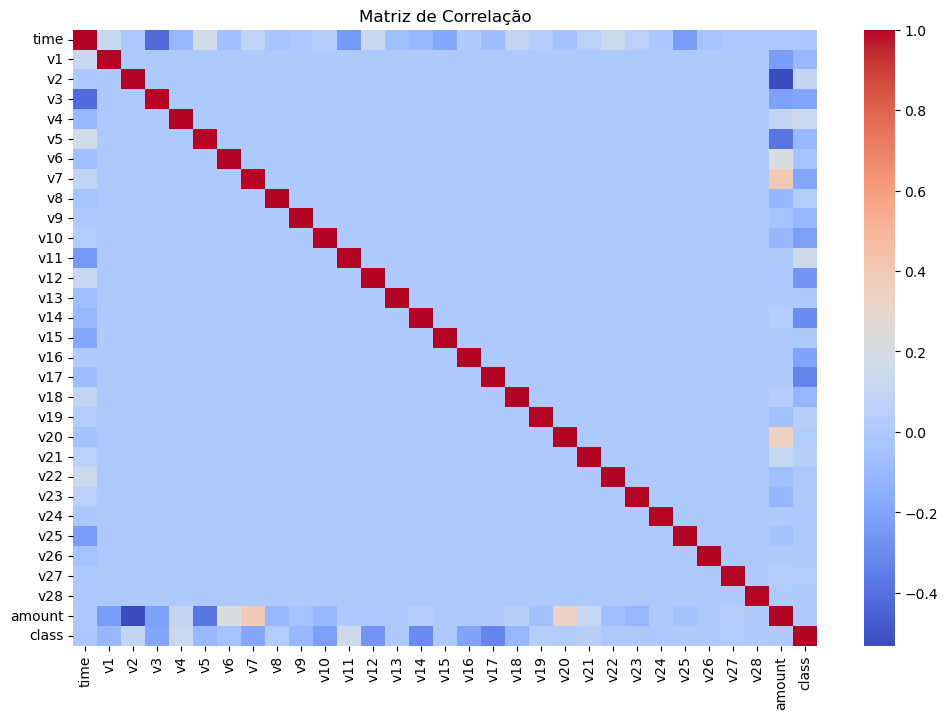

In [7]:
# Correlação das variaveis (v1-v28 + Amount)
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Matriz de Correlação')
plt.show()

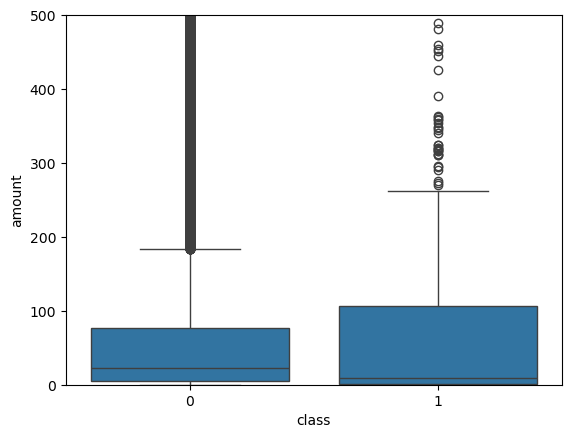

0 null values


In [10]:
#Distribuição de Amount e Time
sns.boxplot(x='class', y='amount', data=df)
plt.ylim(0, 500)
plt.show()
# Procurando valores nulos no Df
print(f"{df.isna().any().sum()} null values")

In [20]:
# Pré - Processamento dos dados 
# Divisão dos dados em train, validation e test
from sklearn.model_selection import train_test_split
# Usado para Feature engineering onde iremos tirar os outliers
from sklearn.preprocessing import RobustScaler
# Utilizado na avaliação dos modelos
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
# Salvar e carregar o modelo(docker)
import joblib

# Separar features e target - Transações reais(0) e fraudulentas(1), Lembrando que Y = Xw + w0 
X = df.drop('class', axis=1)          # df já está com todas as colunas em minúsculo
y = df['class']
# Removendo Outliers
scaler = RobustScaler()
cols_to_scale = ['time', 'amount']
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

# Dividindo os dados (o metodo stratify é usado para dividir igualmente so valores de y entre as divisões já que é uma porção menor)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify= y)

# Conferindo se a divisão ficou proporcional
print(f"Treino: {y_train.value_counts(normalize=True)}")
print(f"Teste : {y_test.value_counts(normalize=True)}")

Treino: class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Teste : class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Função para Testar todos os modelos
def treinar_e_avaliar(modelo, nome):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, "predict_proba") else None
    
    print(f"\n=== {nome} ===")
    print(classification_report(y_test, y_pred))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_prob if y_prob is not None else modelo.decision_function(X_test)):.4f}")
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {nome}')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()
    
    return modelo



=== Regressão Logística ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

AUC-ROC: 0.9720


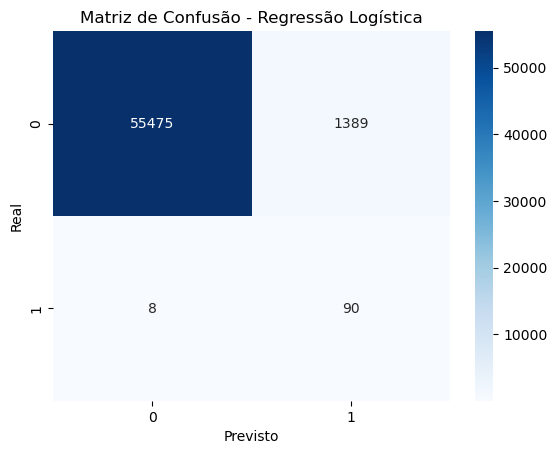

In [22]:
# 1. Regressão Logística
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr = treinar_e_avaliar(lr, "Regressão Logística")


=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9572


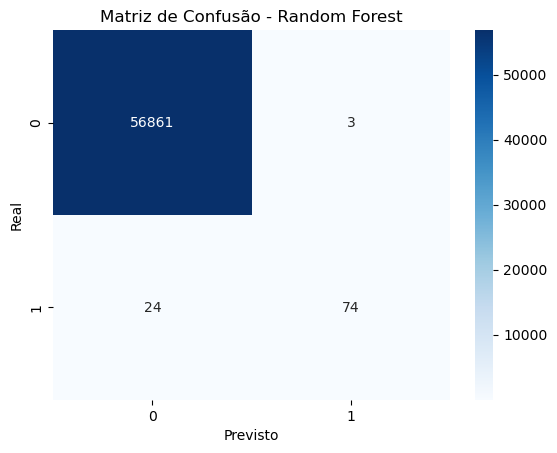

In [23]:
# 2. Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf = treinar_e_avaliar(rf, "Random Forest")

/home/marcus-vinicius/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



=== SVM ===
              precision    recall  f1-score   support

           0       1.00      0.61      0.76     56864
           1       0.00      0.37      0.00        98

    accuracy                           0.61     56962
   macro avg       0.50      0.49      0.38     56962
weighted avg       1.00      0.61      0.75     56962

AUC-ROC: 0.5342


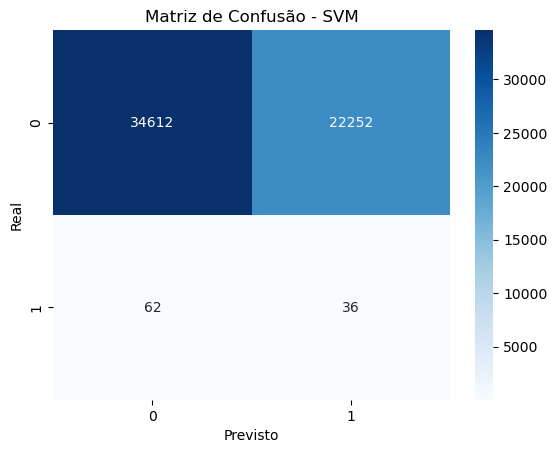

In [24]:
# 3. SVM
svm = SVC(
    kernel='linear',
    class_weight='balanced',
    probability=True,   # necessário para ROC
    random_state=42,
    max_iter=1000
)
svm = treinar_e_avaliar(svm, "SVM")

In [25]:
# Salvar o melhor modelo + scaler
melhor_modelo = rf  # ou o que tiver melhor F1/AUC
joblib.dump(melhor_modelo, 'modelo_fraude_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Modelo e scaler salvos com sucesso!")

Modelo e scaler salvos com sucesso!
